In [35]:
import pandas as pd
import numpy as np

# 1. Đọc toàn bộ dữ liệu (Chưa sample vội để không làm mất dấu Attack)
file_path = '/content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
print("Đang quét toàn bộ file để lọc tấn công...")
df_full = pd.read_csv(file_path, low_memory=False)
df_full.columns = df_full.columns.str.strip()

# 2. Dọn dẹp giá trị lỗi trước khi chia nhóm
df_full.replace([np.inf, -np.inf], np.nan, inplace=True)
df_full.dropna(inplace=True)

# 3. Chia dữ liệu thành các nhóm riêng biệt dựa trên nhãn thực tế
# Lưu ý: Tên nhãn trong file này rất 'dị', có thể có dấu gạch ngang dài
benign_data = df_full[df_full['Label'] == 'BENIGN']
attack_data = df_full[df_full['Label'] != 'BENIGN']

print(f"Tìm thấy: {len(benign_data)} dòng Benign và {len(attack_data)} dòng Attack tổng cộng.")

# 4. CHIẾN THUẬT CÂN BẰNG:
# Lấy toàn bộ dòng Attack (vì chúng ít)
# Và lấy một lượng Benign tương đương (ví dụ gấp 2 lần chỗ Attack cho nó thực tế)
num_benign_to_keep = len(attack_data) * 2
df_benign_sampled = benign_data.sample(n=num_benign_to_keep, random_state=42)

# Gộp lại thành bộ dữ liệu cân bằng
df_balanced = pd.concat([df_benign_sampled, attack_data])

# Trộn đều (Shuffle) để AI không đoán theo thứ tự
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Tách nhãn và lọc cột số (giống như cũ)
y = df["Label"]
df = df.select_dtypes(include=[np.number])
df.fillna(0, inplace=True)

print("--- KẾT QUẢ SAU KHI CÂN BẰNG ---")
print(f"Tổng số dòng dùng để Train/Test: {len(df)}")
print("Số lượng từng loại nhãn:")
print(y.value_counts())

Đang quét toàn bộ file để lọc tấn công...
Tìm thấy: 168051 dòng Benign và 2180 dòng Attack tổng cộng.
--- KẾT QUẢ SAU KHI CÂN BẰNG ---
Tổng số dòng dùng để Train/Test: 6540
Số lượng từng loại nhãn:
Label
BENIGN                        4360
Web Attack � Brute Force      1507
Web Attack � XSS               652
Web Attack � Sql Injection      21
Name: count, dtype: int64


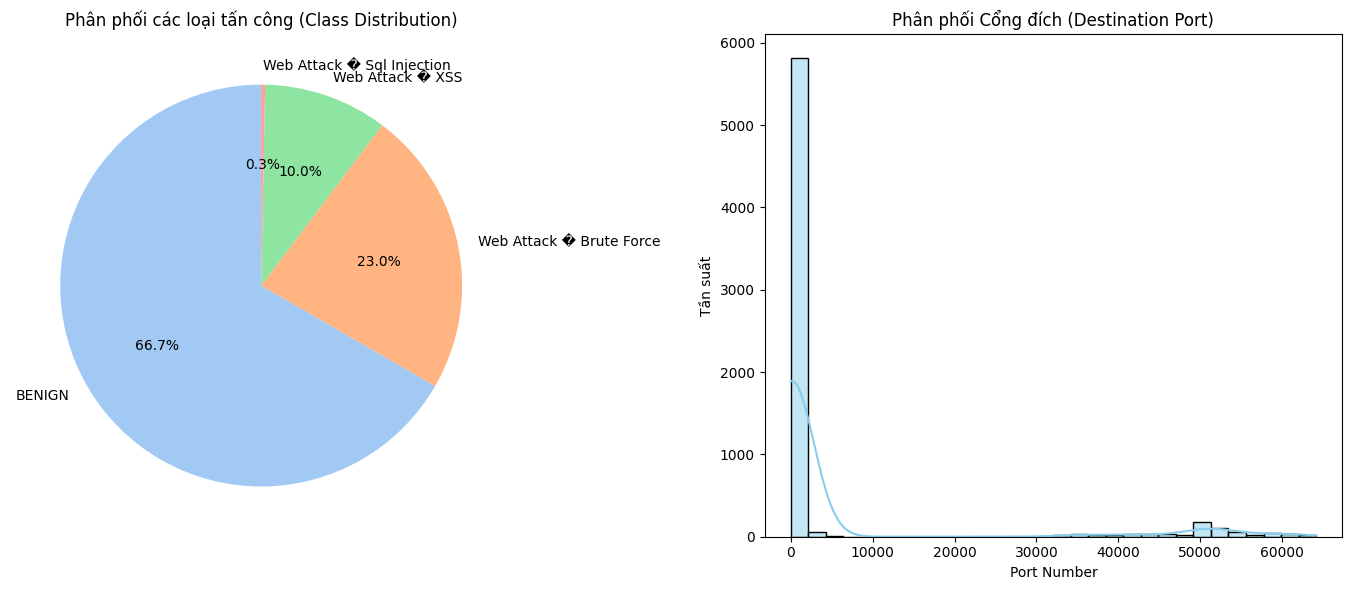

In [36]:
# --- SỬA LẠI PHẦN VẼ BIỂU ĐỒ ---
plt.figure(figsize=(14, 6))

# 1. Biểu đồ tròn cho các loại nhãn (Class Distribution)
plt.subplot(1, 2, 1)
class_counts = y.value_counts()
# Vẽ biểu đồ tròn
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Phân phối các loại tấn công (Class Distribution)')

# 2. Biểu đồ phân phối của một tính năng quan trọng (Feature Distribution)
# Trong bộ Web Attacks, 'Destination Port' là cột rất quan trọng
plt.subplot(1, 2, 2)
if 'Destination Port' in df.columns:
    sns.histplot(df['Destination Port'], kde=True, bins=30, color='skyblue')
    plt.title('Phân phối Cổng đích (Destination Port)')
    plt.xlabel('Port Number')
    plt.ylabel('Tần suất')
else:
    # Nếu không tìm thấy Port, vẽ đại diện cột đầu tiên của dữ liệu
    sns.histplot(df.iloc[:, 0], kde=True, bins=30, color='salmon')
    plt.title(f'Phân phối của {df.columns[0]}')

plt.tight_layout()
plt.show()

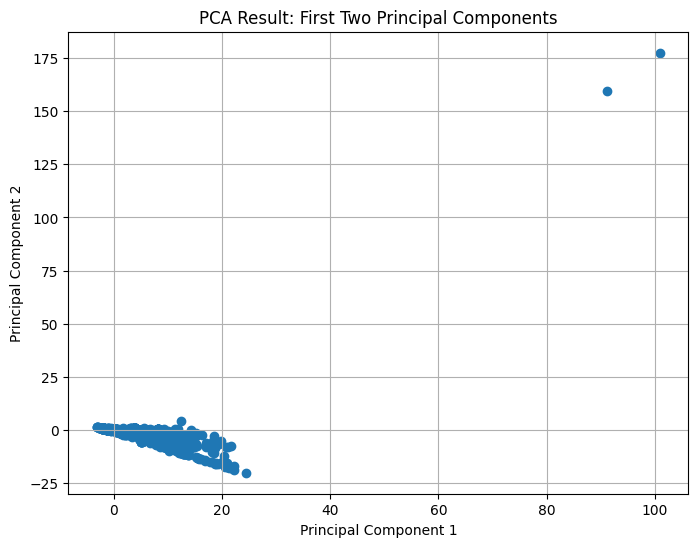

Number of features pre-PCA: 78
Number of features post-PCA: 2


In [37]:
# Scale numerical features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Plot PCA Results
plt.figure(figsize=(8, 6))
plt.scatter(principal_df['PC1'], principal_df['PC2'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result: First Two Principal Components')
plt.grid(True)
plt.show()

print(f"Number of features pre-PCA: {df.shape[1]}")
print(f"Number of features post-PCA: {principal_df.shape[1]}")

In [38]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_scaled, y, test_size=0.3, random_state=42)

# Identify categorical columns for encoding
categorical_cols = df.select_dtypes(include='object').columns

# Apply Frequency Encoding to categorical features
for col in categorical_cols:
    frequency_map = X_train[col].value_counts().to_dict()
    X_train[f"{col}_frequency"] = X_train[col].map(frequency_map)
    X_test[f"{col}_frequency"] = X_test[col].map(frequency_map).fillna(0)
    X_train.drop([col], axis=1, inplace=True)
    X_test.drop([col], axis=1, inplace=True)

# Final scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Final shape of X_train: {X_train.shape}")
print(f"Final shape of X_test: {X_test.shape}")


Final shape of X_train: (4578, 78)
Final shape of X_test: (1962, 78)


In [39]:
!pip install qiskit-aer


In [40]:
!pip install qiskit qiskit-machine-learning


In [41]:
import qiskit
import qiskit_machine_learning
print("Qiskit version:", qiskit.__version__)
print("Qiskit Machine Learning version:", qiskit_machine_learning.__version__)

Qiskit version: 2.3.0
Qiskit Machine Learning version: 0.9.0


In [42]:
import torch
import torch.nn as nn
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.primitives import StatevectorSampler as Sampler

# Define Quantum Circuit with feature map and ansatz
n_qubits = 8  # Set number of qubits
feature_map = ZZFeatureMap(n_qubits)
ansatz = RealAmplitudes(n_qubits, reps=1)
qc = QuantumCircuit(n_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

# Use QNN with Sampler backend
sampler = Sampler()
qnn = SamplerQNN(circuit=qc, input_params=feature_map.parameters, weight_params=ansatz.parameters, sampler=sampler)

# Connect Quantum Model with PyTorch
quantum_model = TorchConnector(qnn)

print(qc.draw(output='text'))


/tmp/ipykernel_239/2079079672.py:11: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(n_qubits)
/tmp/ipykernel_239/2079079672.py:12: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(n_qubits, reps=1)


     ┌────────────────────────────────────────────────────────┐»
q_0: ┤0                                                       ├»
     │                                                        │»
q_1: ┤1                                                       ├»
     │                                                        │»
q_2: ┤2                                                       ├»
     │                                                        │»
q_3: ┤3                                                       ├»
     │  ZZFeatureMap(x[0],x[1],x[2],x[3],x[4],x[5],x[6],x[7]) │»
q_4: ┤4                                                       ├»
     │                                                        │»
q_5: ┤5                                                       ├»
     │                                                        │»
q_6: ┤6                                                       ├»
     │                                                        │»
q_7: ┤7                  

In [43]:
import torch
import torch.nn as nn
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.primitives import StatevectorSampler as Sampler

# Step 1: Define Quantum Circuit with feature map and ansatz
n_qubits = 8
feature_map = ZZFeatureMap(n_qubits)  # Encodes classical data into quantum states
ansatz = RealAmplitudes(n_qubits, reps=1)  # Quantum trainable layer

# Combine feature map and ansatz into a single circuit
qc = QuantumCircuit(n_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

# Step 2: Define QNN using Qiskit Sampler
sampler = Sampler()
qnn = SamplerQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    sampler=sampler
)

# Step 3: Convert QNN to PyTorch model using TorchConnector
quantum_model = TorchConnector(qnn)

# Print model summary to check compatibility
print("Quantum CNN Model initialized successfully! ")
print(quantum_model)

print(qc.draw(output='text'))



/tmp/ipykernel_239/2148059674.py:11: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(n_qubits)  # Encodes classical data into quantum states
/tmp/ipykernel_239/2148059674.py:12: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(n_qubits, reps=1)  # Quantum trainable layer


Quantum CNN Model initialized successfully! 
TorchConnector()
     ┌────────────────────────────────────────────────────────┐»
q_0: ┤0                                                       ├»
     │                                                        │»
q_1: ┤1                                                       ├»
     │                                                        │»
q_2: ┤2                                                       ├»
     │                                                        │»
q_3: ┤3                                                       ├»
     │  ZZFeatureMap(x[0],x[1],x[2],x[3],x[4],x[5],x[6],x[7]) │»
q_4: ┤4                                                       ├»
     │                                                        │»
q_5: ┤5                                                       ├»
     │                                                        │»
q_6: ┤6                                                       ├»
     │                      

In [44]:
!pip install torchmetrics

Epoch 0 | QCNN Loss: 1.4316 Acc: 0.1468
Epoch 0 | CNN Loss: 1.4266 Acc: 0.0609
Epoch 10 | QCNN Loss: 0.8989 Acc: 0.6767
Epoch 10 | CNN Loss: 1.0859 Acc: 0.8084
Epoch 20 | QCNN Loss: 0.6925 Acc: 0.6868
Epoch 20 | CNN Loss: 0.7614 Acc: 0.8316
Epoch 30 | QCNN Loss: 0.5847 Acc: 0.7774
Epoch 30 | CNN Loss: 0.5255 Acc: 0.8445
Epoch 40 | QCNN Loss: 0.5206 Acc: 0.8165
Epoch 40 | CNN Loss: 0.4298 Acc: 0.8432


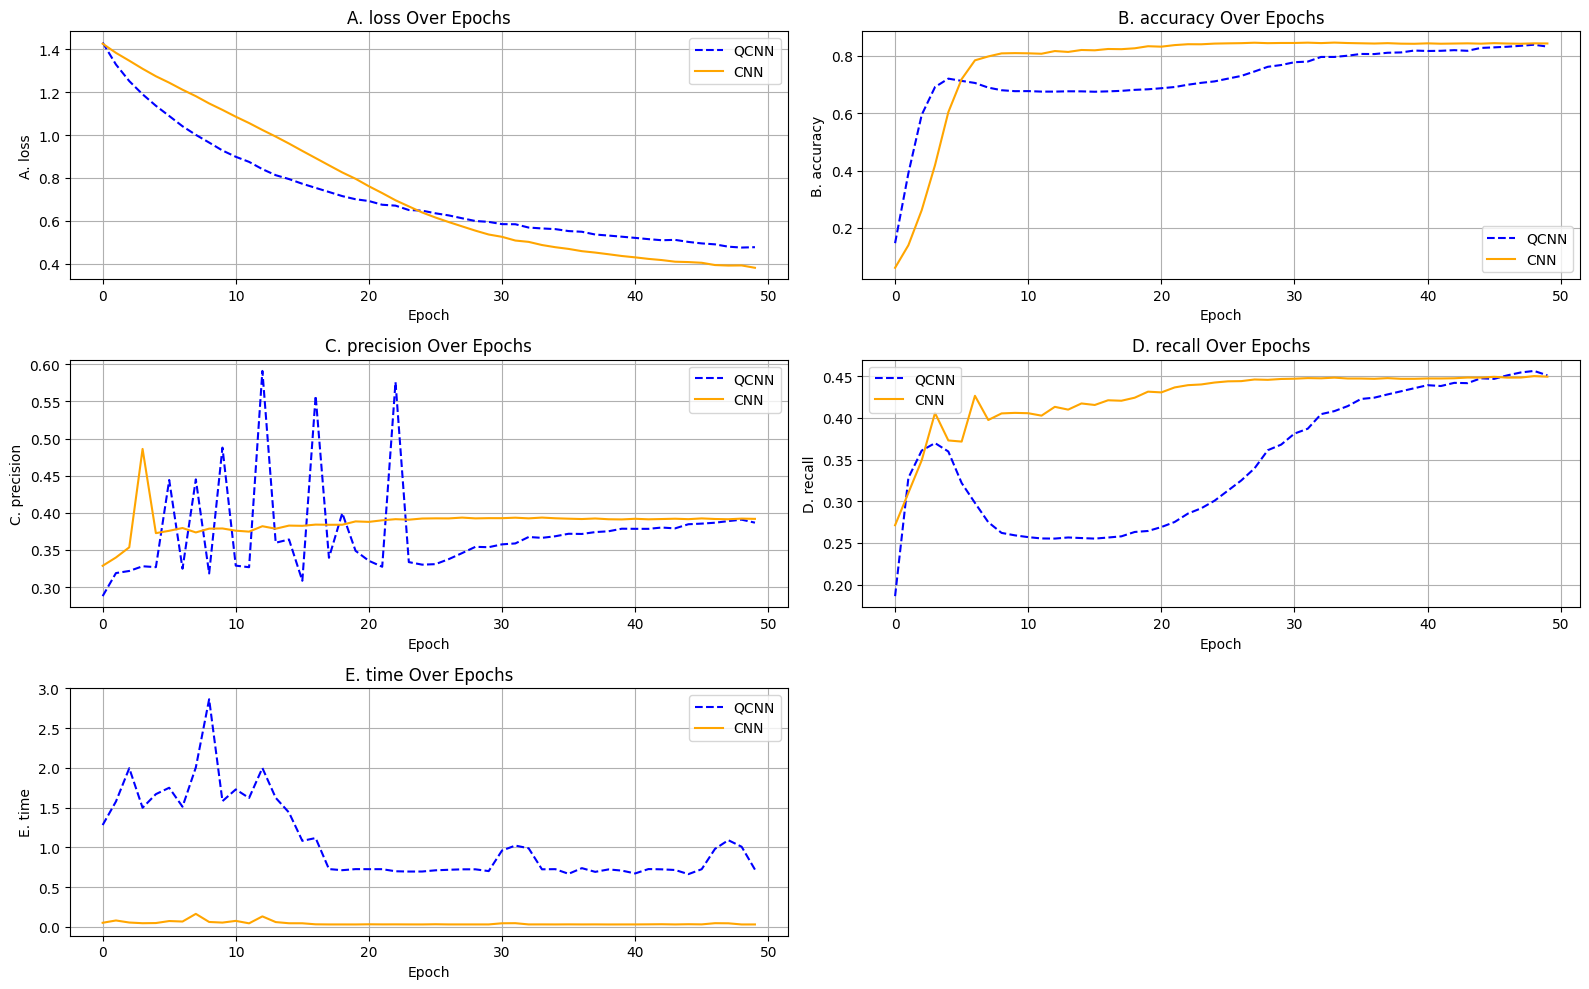

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import torchmetrics
from torch.nn import CrossEntropyLoss
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import time
from torch.optim import AdamW

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define CNN model
class ClassicalCNN(nn.Module):
   def __init__(self, input_dim, num_classes):
       super(ClassicalCNN, self).__init__()
       self.model = nn.Sequential(
           nn.Linear(input_dim, 128),
           nn.ReLU(),
          nn.Dropout(0.3),
           nn.Linear(128, 64),
          nn.ReLU(),
           nn.Dropout(0.3),
          nn.Linear(64, num_classes)
      )

   def forward(self, x):
       return self.model(x)

#Define QCnn Model
class QuantumCNN(nn.Module):
   def __init__(self, input_dim, num_classes=2):
        super(QuantumCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(64, 256, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(256, 64)
        self.dropout = nn.Dropout(0.5)
        self.out = nn.Linear(64, num_classes)

   def forward(self, x):
        x = x.unsqueeze(1)

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.global_avg_pool(x).squeeze(-1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.out(x)  # logits

# Prepare data
# n_qubits = 8
# num_classes = len(np.unique(y_train))

# X_train_qcnn_t = torch.tensor(X_train[:, :n_qubits], dtype=torch.float32).to(device)
# X_test_qcnn_t = torch.tensor(X_test[:, :n_qubits], dtype=torch.float32).to(device)
# X_train_cnn_t = torch.tensor(X_train, dtype=torch.float32).to(device)
# X_test_cnn_t = torch.tensor(X_test, dtype=torch.float32).to(device)
# y_train_t = torch.tensor(y_train.values, dtype=torch.long).to(device)
# y_test_t = torch.tensor(y_test.values, dtype=torch.long).to(device)

# 1. Chuyển X_train, X_test từ DataFrame/Series sang Numpy Array trước
X_train_np = X_train.to_numpy() if hasattr(X_train, 'to_numpy') else np.array(X_train)
X_test_np = X_test.to_numpy() if hasattr(X_test, 'to_numpy') else np.array(X_test)

# 2. Ép kiểu dữ liệu sang float32 (PyTorch cực thích kiểu này)
X_train_np = X_train_np.astype(np.float32)
X_test_np = X_test_np.astype(np.float32)

# 3. Chuyển sang Tensor và đưa lên thiết bị (CPU/GPU)
X_train_cnn_t = torch.tensor(X_train_np).to(device)
X_test_cnn_t = torch.tensor(X_test_np).to(device)

# 4. Đối với QCNN (chỉ lấy n_qubits đặc trưng đầu tiên)
X_train_qcnn_t = X_train_cnn_t[:, :n_qubits]
X_test_qcnn_t = X_test_cnn_t[:, :n_qubits]

# 5. Xử lý nhãn (như đã làm ở bước trước)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_t = torch.tensor(y_train_encoded, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test_encoded, dtype=torch.long).to(device)

num_classes = len(le.classes_)

# Instantiate models
classical_model = ClassicalCNN(input_dim=X_train.shape[1], num_classes=num_classes).to(device)
quantum_model = QuantumCNN(input_dim=n_qubits, num_classes=num_classes).to(device)

# Optimizer & Loss
optimizer_cnn = Adam(classical_model.parameters(), lr=0.001)
optimizer_qcnn = AdamW(quantum_model.parameters(), lr=0.0005, weight_decay=1e-4)

loss_fn = CrossEntropyLoss()

# Training loop with full metrics
epochs = 50
metrics = {
    'cnn': {'a. loss': [], 'b. accuracy': [], 'c. precision': [], 'd. recall': [], 'e. time': []},
    'qcnn': {'a. loss': [], 'b. accuracy': [], 'c. precision': [], 'd. recall': [], 'e. time': []}
}

for epoch in range(epochs):
    for name, model, optimizer, X_input in zip(['qcnn', 'cnn'], [quantum_model, classical_model], [optimizer_qcnn, optimizer_cnn], [X_train_qcnn_t, X_train_cnn_t]):
        model.train()
        optimizer.zero_grad()

        start_time = time.time()

        output = model(X_input)
        loss = loss_fn(output, y_train_t)
        loss.backward()
        optimizer.step()

        pred = output.argmax(dim=1)
        acc = (pred == y_train_t).float().mean().item()
        prec = torchmetrics.functional.precision(pred, y_train_t, average='macro', num_classes=num_classes, task="multiclass")
        rec = torchmetrics.functional.recall(pred, y_train_t, average='macro', num_classes=num_classes, task="multiclass")

        end_time = time.time()
        elapsed_time = end_time - start_time

        metrics[name]['a. loss'].append(loss.item())
        metrics[name]['b. accuracy'].append(acc)
        metrics[name]['c. precision'].append(prec.item())
        metrics[name]['d. recall'].append(rec.item())
        metrics[name]['e. time'].append(elapsed_time)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | {name.upper()} Loss: {loss.item():.4f} Acc: {acc:.4f}")

# Plotting Curves
plt.figure(figsize=(16, 10))
for i, metric in enumerate(['a. loss', 'b. accuracy', 'c. precision', 'd. recall', 'e. time']):
    plt.subplot(3, 2, i+1)
    plt.plot(metrics['qcnn'][metric], label='QCNN', linestyle='--', color='blue')
    plt.plot(metrics['cnn'][metric], label='CNN', linestyle='-', color='orange')
    plt.title(f'{metric.capitalize()} Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()




QCNN Performance


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.94      0.93      0.94      1290
           1       0.58      0.87      0.70       458
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00       209

    accuracy                           0.82      1962
   macro avg       0.38      0.45      0.41      1962
weighted avg       0.76      0.82      0.78      1962


CNN Performance
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1290
           1       0.63      0.84      0.72       458
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00       209

    accuracy                           0.84      1962
   macro avg       0.39      0.45      0.42      1962
weighted avg       0.76      0.84      0.79      1962



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

<Figure size 500x400 with 0 Axes>

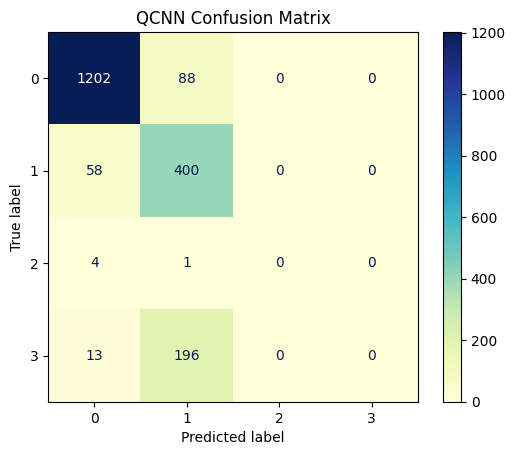

<Figure size 500x400 with 0 Axes>

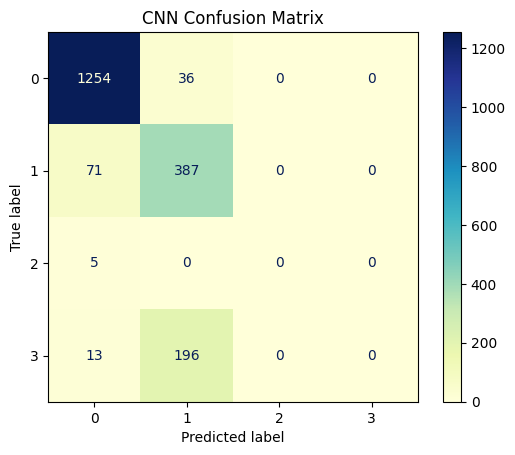

In [46]:
# Evaluate on test set
y_pred_qcnn = quantum_model(X_test_qcnn_t).detach().cpu().numpy()
y_pred_cnn = classical_model(X_test_cnn_t).detach().cpu().numpy()
y_pred_qcnn_labels = np.argmax(y_pred_qcnn, axis=1)
y_pred_cnn_labels = np.argmax(y_pred_cnn, axis=1)

# Classification Report
for name, y_pred in zip(["QCNN", "CNN"], [y_pred_qcnn_labels, y_pred_cnn_labels]):
    print(f"\n{name} Performance")
    print(classification_report(y_test_encoded, y_pred))

# Confusion Matrices
for name, y_pred in zip(["QCNN", "CNN"], [y_pred_qcnn_labels, y_pred_cnn_labels]):
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test_encoded, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap='YlGnBu')
    plt.title(f'{name} Confusion Matrix')
    plt.grid(False)
    plt.show()

# ROC Curve (Binary classification only)
if num_classes == 2:
    plt.figure(figsize=(6, 5))
    fpr, tpr, _ = roc_curve(y_test, y_pred_qcnn[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"QCNN (AUC = {roc_auc:.2f})", color='blue')

    fpr, tpr, _ = roc_curve(y_test, y_pred_cnn[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"CNN (AUC = {roc_auc:.2f})", color='orange')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()
